# Notebook to create a GPX file from screenshots of the track
Needed imports.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from datetime import datetime, timedelta
from PIL import Image
import pandas as pd

import gpxpy
import gpxpy.gpx
import xml.etree.ElementTree as ET

### Important parameters

In [2]:
activity_number = 1

reftime = datetime(2025, 9, 9, 11, 24, 31)
# reftime = datetime(2025, 9, 9, 9, 34, 11)

### Reading the image

In [3]:
IMAGE_PATH = f"data/activity{activity_number}/screenshot_gps.jpg"
OUTPUT_GPX = f"output/recovered_track_{activity_number}.gpx"

img_array = np.asarray(Image.open(IMAGE_PATH))
h, w = img_array.shape[:2]

Use (x, y) test for constructing the pixel-geographical coorinates and checking in google maps the coordinates of these points (https://www.google.es/maps)

In [4]:
x1, y1 = 170, 485
x2, y2 = 840, 595

# x1, y1 = 130, 355
# x2, y2 = 1020, 700

lat1, lon1 = 28.765731, -17.749451
lat2, lon2 = 28.765397, -17.747123

# lat1, lon1 = 28.768611, -17.751268
# lat2, lon2 = 28.767689, -17.748478

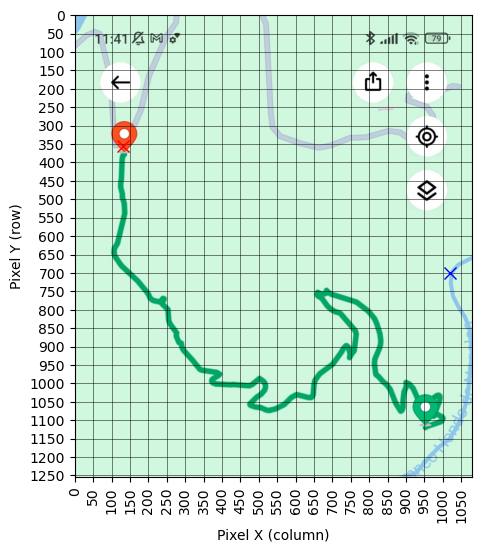

In [5]:
plt.figure(figsize=(10,6))
plt.imshow(img_array)
plt.plot(x1, y1, "rx", markersize=8)
plt.plot(x2, y2, "bx", markersize=8)
plt.xlabel("Pixel X (column)"); plt.ylabel("Pixel Y (row)")
plt.xlim(0, w-1); plt.ylim(h-1, 0); plt.grid(color="k", linestyle="-", linewidth=0.5, alpha=0.7)
plt.xticks(np.arange(0, w, 50), rotation=90); plt.yticks(np.arange(0, h, 50))
plt.show()

### Converting pixel-geom coordinates

In [6]:
# Parameters for linear interpolation for coordinates
A, C = (lon2 - lon1) / (x2 - x1), (lat2 - lat1) / (y2 - y1)
B, D = lon1 - A * x1, lat1 - C * y1

# Image pixels into coordinates
array_lon = A * np.arange(w) + B
array_lat = C * np.arange(h) + D

#### Reading the data obtained from WebPlotDigitalizer (https://apps.automeris.io/wpd4/)

In [7]:
track_df        = pd.read_csv(f"data/activity{activity_number}/dataset_gps.csv", header=None)
dataset_hr      = pd.read_csv(f"data/activity{activity_number}/dataset_hr.csv", header=None)
dataset_cadence = pd.read_csv(f"data/activity{activity_number}/dataset_cadence.csv", header=None)
dataset_stride  = pd.read_csv(f"data/activity{activity_number}/dataset_stride.csv", header=None)

track_pixels = track_df[[0,1]].to_numpy()
track_lon = A * track_pixels[:,0] + B
track_lat = C * track_pixels[:,1] + D
print(f"Loaded {len(track_pixels)} track points from CSV")

t_off_hr, hr           = np.array([timedelta(minutes=d) for d in dataset_hr[0]]),      dataset_hr[1].to_numpy()
t_off_cadence, cadence = np.array([timedelta(minutes=d) for d in dataset_cadence[0]]), dataset_cadence[1].to_numpy()
t_off_stride, stride   = np.array([timedelta(minutes=d) for d in dataset_stride[0]]),  dataset_stride[1].to_numpy()

# Absolute datetimes
t_hr      = reftime + t_off_hr
t_cadence = reftime + t_off_cadence
t_stride  = reftime + t_off_stride

# Time offsets in seconds
dt_hr      = np.array([t.total_seconds() for t in t_off_hr])
dt_cadence = np.array([t.total_seconds() for t in t_off_cadence])
dt_stride  = np.array([t.total_seconds() for t in t_off_stride])

Loaded 207 track points from CSV


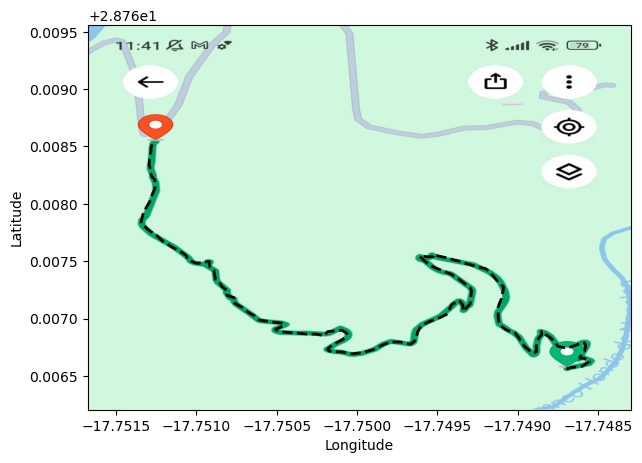

In [8]:
plt.figure(figsize=(7,5))
plt.imshow(img_array, aspect="auto",extent=[array_lon[0], array_lon[-1], array_lat[-1], array_lat[0]])
plt.plot(track_lon, track_lat, "--", linewidth=2, color="k")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.show()

### 1 Second sampling

In [9]:
t_start = np.min([t_hr[0], t_cadence[0], t_stride[0]])
t_end   = np.max([t_hr[-1], t_cadence[-1], t_stride[-1]])
t_array = pd.date_range(start=t_start, end=t_end, freq="1s")

duration_sec = (t_end-t_start).total_seconds()

# Interpolated time sample
dt_i = np.arange(0, duration_sec + 1, 1)
t_i  = [reftime + timedelta(seconds=dt) for dt in dt_i]

# Interpolating data
interp_hr      = interp1d(dt_hr, hr, kind="linear", bounds_error=False, fill_value="extrapolate")
interp_cadence = interp1d(dt_cadence, cadence, kind="linear", bounds_error=False, fill_value="extrapolate")
interp_stride  = interp1d(dt_stride, stride, kind="linear", bounds_error=False, fill_value="extrapolate")

hr_i      = np.where(interp_hr(dt_i)<=0, 0.0, interp_hr(dt_i))
cadence_i = np.where(interp_cadence(dt_i)<=0, 0.0, interp_cadence(dt_i))
stride_i  = np.where(interp_stride(dt_i)<=0, 0.0, interp_stride(dt_i)) 

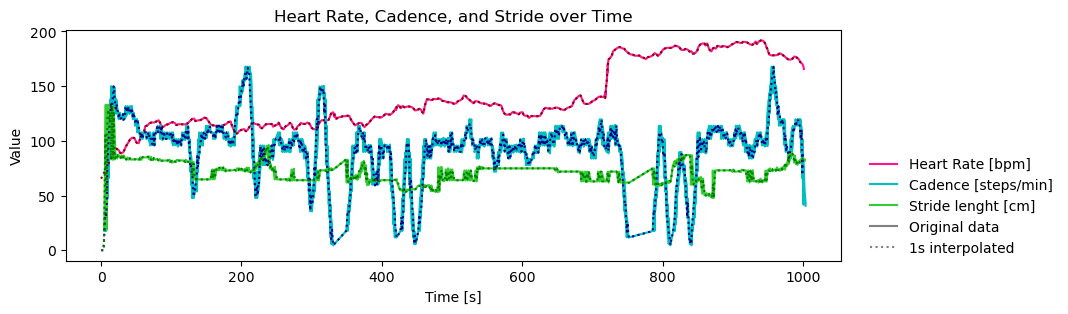

In [10]:
plt.figure(figsize=(10,3))
plt.plot(dt_hr, hr, "-", label="Heart Rate [bpm]", color="deeppink")
plt.plot(dt_cadence, cadence, "-", label="Cadence [steps/min]", color="c")
plt.plot(dt_stride, stride, "-", label="Stride lenght [cm]", color="limegreen")
plt.plot(dt_i, hr_i, ":", color="maroon")
plt.plot(dt_i, cadence_i, ":", color="darkblue")
plt.plot(dt_i, stride_i, ":", color="green")
plt.plot([], [], color="gray", ls="-", label="Original data")
plt.plot([], [], color="gray", ls=":", label="1s interpolated")

plt.xlabel("Time [s]"); plt.ylabel("Value"); plt.title("Heart Rate, Cadence, and Stride over Time")
plt.legend(loc=(1.03, 0), frameon=False)
plt.show()

### Getting the distances, via coodinates and via data

In [11]:
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371000  # Earth radius in meters
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlambda = radians(lon2 - lon1)
    a = sin(dphi/2)**2 + cos(phi1)*cos(phi2)*sin(dlambda/2)**2
    c = 2*atan2(sqrt(a), sqrt(1-a))
    return R * c

distances = np.array([
    haversine(track_lat[i], track_lon[i], track_lat[i+1], track_lon[i+1]) for i in range(len(track_lat)-1)
])
cum_dist = np.insert(np.cumsum(distances), 0, 0)

distance_per_second = stride_i / 100 * (cadence_i / 60) # m/s
cum_dist_est = np.cumsum(distance_per_second)

total_distance = cum_dist_est[-1]
scale_factor     = total_distance / cum_dist[-1]
scale_factor_est = total_distance / cum_dist_est[-1]
cum_dist     *= scale_factor
cum_dist_est *= scale_factor_est

# Interpolating spatially
interp_lat = interp1d(cum_dist, track_lat, kind="linear")
interp_lon = interp1d(cum_dist, track_lon, kind="linear")
lat_i = interp_lat(cum_dist)
lon_i = interp_lon(cum_dist)

### Writing on disk the file

In [12]:
gpx = gpxpy.gpx.GPX()
gpx_track = gpxpy.gpx.GPXTrack()
gpx.tracks.append(gpx_track)
gpx_segment = gpxpy.gpx.GPXTrackSegment()
gpx_track.segments.append(gpx_segment)

speed_i = stride_i / 100 * (cadence_i / 60.0) # m / s

# Adding information
for lat, lon, time, hr, cad, spd in zip(lat_i, lon_i, t_i, hr_i, cadence_i, speed_i):
    point = gpxpy.gpx.GPXTrackPoint(latitude=lat, longitude=lon, elevation=0, time=time)

    # Create XML extensions
    ext = ET.Element("gpxtpx:TrackPointExtension")
    hr_elem = ET.SubElement(ext, "gpxtpx:hr")
    hr_elem.text = str(int(hr))
    cad_elem = ET.SubElement(ext, "gpxtpx:cad")
    cad_elem.text = str(int(cad))

    # Optional: adding speed
    spd_elem = ET.SubElement(ext, "speed")
    spd_elem.text = f"{spd:.2f}"

    point.extensions.append(ext)
    gpx_segment.points.append(point)

# Write GPX to file
with open(f"output/reconstructed_track_{activity_number}.gpx", "w") as f:
    f.write(gpx.to_xml())